> **Uso de IAG en este proyecto**  
> Este cuaderno fue desarrollado como parte del proyecto de grado  
> *"Análisis de temblor con sensores inerciales (IMU) para la detección de inestabilidad postural en pacientes con Parkinson"*.  
> Se utilizaron herramientas de Inteligencia Artificial Generativa (IAG)  
> -- GitHub Copilot y OpenCode (modelo deepseek-v4-flash) -- para:  
> - Generación y depuración de código Python (carga de datos, preprocesamiento, análisis espectral, visualización).  
> - Asistencia en estructuración de cuadernos Jupyter y documentación técnica.  
> - Revisión de lógica de detección de temblor y clasificación MDS-UPDRS.  
>  
> Todo el código generado fue revisado, validado y ajustado por los autores  
> para garantizar su corrección técnica y alineación con los objetivos clínicos del estudio.  
>  
> **Citación:** Herramientas de IAG (GitHub Copilot, OpenCode) utilizadas  
> en el desarrollo de este proyecto de grado, 2025-2026.

# Análisis IMU - Manos extendidas (10s)

Este cuaderno carga datos IMU desde un archivo JSON de la carpeta `19_oct_imus`, extrae señales de acelerómetro y giróscopo por dispositivo (por ejemplo, LEFT-HAND, RIGHT-HAND, BASE-SPINE), calcula métricas y detecta temblor en la banda típica de parkinsonismo (aprox. 3–8 Hz). También genera gráficos explicativos de tiempo y espectro.

Instrucciones rápidas:
- Ajusta la variable `json_path` en la siguiente celda si deseas analizar otro archivo.
- Ejecuta las celdas en orden. Las dependencias usan alternativas para minimizar instalaciones.
- El detector reporta frecuencia pico de temblor, potencia relativa y una bandera booleana por dispositivo.


In [13]:

# IAG: Celdas de imports y funciones de utilidad asistidas por IAG (OpenCode / GitHub Copilot).
# Imports y utilidades básicas (con alternativas si SciPy no está disponible)
from __future__ import annotations
import json
import math
import os
from typing import Dict, Tuple, Optional
import numpy as np
import pandas as pd

# Gráficos: preferimos matplotlib; si no está disponible, intentaremos plotly como alternativa
try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.express as px
        import plotly.graph_objects as go
    except Exception:
        px = None
        go = None

# Señales: SciPy si existe; si no, implementamos alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024) -> Tuple[np.ndarray, np.ndarray]:
    """Welch PSD con NumPy puro como alternativa a scipy.signal.welch."""
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = nperseg // 2
    if step <= 0:
        step = 1
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start:start + nperseg]
        seg = seg - np.mean(seg)
        segs.append(seg * win)
    if not segs:
        segs = [x - np.mean(x)]
        nperseg = len(segs[0])
        win = np.hanning(nperseg)
        segs[0] = segs[0] * win
    segs = np.stack(segs, axis=0)
    # FFT de cada segmento
    X = np.fft.rfft(segs, axis=1)
    psd = (np.abs(X) ** 2) / (np.sum(win**2) * fs)
    Pxx = np.mean(psd, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024) -> Tuple[np.ndarray, np.ndarray]:
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg=nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    """Filtrado pasa banda. Si SciPy disponible usa butter+filtfilt; si no, filtrado en frecuencia (FFT)."""
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or fs <= 0 or not np.isfinite(fs):
        return np.zeros_like(x)
    low = max(0.0, float(low))
    high = max(low + 1e-3, float(high))
    if _HAVE_SCIPY and fs > 0 and high < fs/2.0:
        try:
            b, a = sps.butter(4, [low/(fs/2.0), high/(fs/2.0)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    # Alternativa: filtrado por enmascaramiento en frecuencia
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    X_f = np.zeros_like(X)
    X_f[mask] = X[mask]
    y = np.fft.irfft(X_f, n=len(x))
    return y

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if len(f) < 2 or len(Pxx) < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [14]:

# IAG: Cargador JSON recursivo asistido por IAG para manejar formatos anidados y alias de clave.
# Selección del archivo JSON a analizar (ajústalo si deseas otro)
from pathlib import Path

# Por defecto usamos el archivo mencionado en la conversación:
json_path = Path("../Datos/Control/3.15-Control.json")
assert Path(json_path).exists(), f"No se encontró el archivo: {json_path}"

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

patient = data.get('patient', {})
test_type = data.get('testType', None)
record_ts = data.get('timestamp', None)
imu_data = data.get('imuData', [])
print(f"Registros IMU: {len(imu_data)} | TestType: {test_type}")
print("Paciente:", patient)

# Convertimos a DataFrame plano
rows = []
for p in imu_data:
    acc = p.get('accelerometer', {}) or {}
    gyr = p.get('gyroscope', {}) or {}
    rows.append({
        'deviceId': p.get('deviceId', 'UNKNOWN'),
        'timestamp_ms': p.get('timestamp', np.nan),
        'ax': acc.get('x', np.nan), 'ay': acc.get('y', np.nan), 'az': acc.get('z', np.nan),
        'gx': gyr.get('x', np.nan), 'gy': gyr.get('y', np.nan), 'gz': gyr.get('z', np.nan),
    })

df = pd.DataFrame(rows)
df = df.dropna(subset=['timestamp_ms', 'deviceId']).sort_values(['deviceId','timestamp_ms']).reset_index(drop=True)
assert not df.empty, "El DataFrame de señales está vacío"
df.head()

Registros IMU: 3490 | TestType: GAIT_ARMS
Paciente: {'birthDate': '20/10/2025', 'id': '12345', 'name': 'Rojas Jojoa Caviedez', 'observations': 'Rojas Prueba brazos extendidos por 10 segundos'}


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,BASE-SPINE,2303,1.072021,0.023315,-0.101440,-2.990723,9.460449,11.47461
1,BASE-SPINE,2329,1.055664,-0.025391,-0.096802,-7.934570,12.084960,10.25391
2,BASE-SPINE,2356,1.042603,-0.028442,-0.080811,-9.277344,12.390140,10.68115
3,BASE-SPINE,2382,1.032959,-0.023682,-0.087891,-10.192870,11.535640,11.16943
4,BASE-SPINE,2408,1.055908,-0.041016,-0.064575,-13.610840,14.526370,11.96289


In [15]:
# Preprocesamiento: tiempo por dispositivo, magnitudes y ventana de 10s
def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms) / 1000.0  # ms -> s
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0/med

# Normalizamos tiempo por dispositivo
df = df.copy()
df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)  # s desde inicio de cada dispositivo

# Magnitudes
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = list(df['deviceId'].dropna().unique())
fs_map: Dict[str, float] = {}
for dev in devices:
    fs_map[dev] = estimate_fs_ms(df.loc[df['deviceId']==dev, 'timestamp_ms'].to_numpy())
fs_map

# Seleccionamos una ventana común de 10s (centrada si hay más duración compartida)
per_dev_max = df.groupby('deviceId')['t'].max()
per_dev_min = df.groupby('deviceId')['t'].min()
global_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
global_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
dur = max(0.0, global_max - global_min)
if dur >= 10.0:
    start_t = global_min + (dur - 10.0)/2.0
    end_t = start_t + 10.0
else:
    start_t = global_min
    end_t = global_max
print(f"Ventana seleccionada: [{start_t:.2f}, {end_t:.2f}] s (dur={end_t-start_t:.2f}s)")

mask = (df['t'] >= start_t) & (df['t'] <= end_t)
df_win = df.loc[mask].copy()
assert not df_win.empty, "No hay datos en la ventana seleccionada"
df_win.head()

Ventana seleccionada: [8.87, 18.87] s (dur=10.00s)


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag
327,BASE-SPINE,11187,1.023315,-0.094238,-0.203735,0.976563,-1.281738,0.000000,8.884,1.047646,1.611374
328,BASE-SPINE,11214,1.028198,-0.097412,-0.203247,0.122070,-1.037598,-0.122070,8.911,1.052611,1.051861
329,BASE-SPINE,11240,1.025879,-0.108887,-0.210205,0.061035,-1.708984,-0.122070,8.937,1.052839,1.714425
330,BASE-SPINE,11292,1.031494,-0.102539,-0.204956,0.000000,-0.671387,0.061035,8.989,1.056646,0.674156
331,BASE-SPINE,11318,1.025146,-0.103882,-0.202393,0.183105,-0.427246,-0.061035,9.015,1.050085,0.468820


In [16]:

# IAG: Implementacion de Welch PSD y deteccion de temblor asistida por IAG, basada en referencias clinicas.
# Detección de temblor: utilidades y función principal
from dataclasses import dataclass

@dataclass
class TremorResult:
    device: str
    signal: str  # 'acc_mag' o 'gyro_mag'
    fs: float
    peak_freq_hz: float
    band_power: float
    total_power: float
    ratio: float
    rms_tremor: float
    band: Tuple[float, float]
    is_tremor: bool

def detect_tremor(sig: np.ndarray, fs: float, band: Tuple[float,float]=(3.0, 8.0),
                  broad: Tuple[float,float]=(0.5, 15.0),
                  rms_threshold: float=0.02) -> Tuple[float,float,float,float,bool]:
    """Devuelve (peak_freq_hz, band_power, total_power, ratio, is_tremor).
    - band: banda de temblor (Hz) típica de parkinsonismo.
    - broad: banda amplia para normalizar potencia (Hz).
    - rms_threshold: umbral en unidades del canal (g para acc, deg/s para gyro)."""
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs*2)):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    x = np.asarray(sig, dtype=float)
    x = x - np.mean(x)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, False)
    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power/total_power) if total_power > 0 else 0.0
    # Frecuencia pico en la banda
    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')
    # Amplitud RMS del componente filtrado en la banda
    y = simple_bandpass(x, fs, band[0], band[1])
    rms = float(np.sqrt(np.mean(y*y))) if y.size else 0.0
    # Heurística: potencia relativa suficiente + amplitud mínima
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, is_tremor)

In [17]:
# Ejecutar detección por dispositivo (acc y gyro)
results = []
for dev in devices:
    sub = df_win[df_win['deviceId']==dev].copy()
    if sub.empty:
        continue
    fs = fs_map.get(dev, float('nan'))
    # Acelerómetro (g): umbral RMS conservador 0.02 g
    acc = sub['acc_mag'].to_numpy()
    pk, bp, tp, r, flag = detect_tremor(acc, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.02)
    results.append(TremorResult(dev, 'acc_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(acc, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))
    # Giróscopo (deg/s): umbral RMS 0.5 deg/s
    gyro = sub['gyro_mag'].to_numpy()
    pk, bp, tp, r, flag = detect_tremor(gyro, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.5)
    results.append(TremorResult(dev, 'gyro_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(gyro, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))

summary = pd.DataFrame([r.__dict__ for r in results])
summary

,device,signal,fs,peak_freq_hz,band_power,total_power,ratio,rms_tremor,band,is_tremor
0,BASE-SPINE,acc_mag,38.461538,3.906250,0.000175,0.000239,0.733089,0.034529,"(3.0, 8.0)",False
1,BASE-SPINE,gyro_mag,38.461538,3.004808,0.655059,2.294794,0.285454,0.648024,"(3.0, 8.0)",False
2,LEFT-HAND,acc_mag,38.461538,3.004808,0.003370,0.014839,0.227068,0.126997,"(3.0, 8.0)",False
3,LEFT-HAND,gyro_mag,38.461538,3.004808,163.556242,640.893390,0.255200,21.279710,"(3.0, 8.0)",False
4,RIGHT-HAND,acc_mag,38.461538,3.004808,0.004659,0.026083,0.178609,0.072753,"(3.0, 8.0)",False
5,RIGHT-HAND,gyro_mag,38.461538,3.305288,424.238239,1502.372136,0.282379,24.995402,"(3.0, 8.0)",False


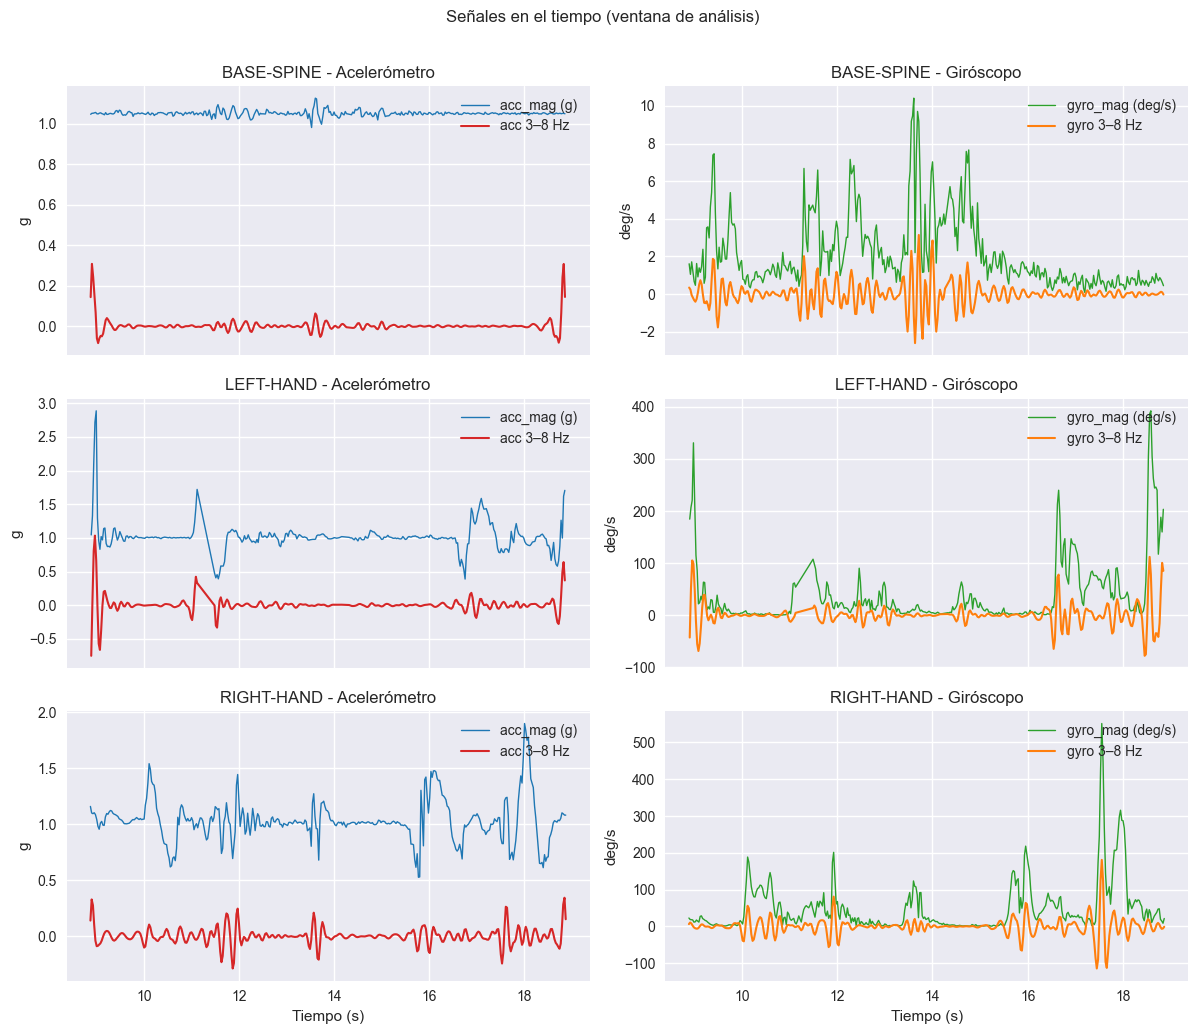

In [18]:
# Gráficos en el tiempo (ventana seleccionada) con componente de temblor (3–8 Hz)
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.5*n), sharex=True)
    if n == 1:
        axes = np.array([axes])
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        ax0 = axes[i,0]
        ax0.plot(t, acc, color='#1f77b4', label='acc_mag (g)', linewidth=1)
        ax0.plot(t, acc_trem, color='#d62728', label='acc 3–8 Hz', linewidth=1.5)
        ax0.set_title(f"{dev} - Acelerómetro")
        ax0.set_ylabel('g')
        ax0.legend(loc='upper right')
        ax1 = axes[i,1]
        ax1.plot(t, gyro, color='#2ca02c', label='gyro_mag (deg/s)', linewidth=1)
        ax1.plot(t, gyro_trem, color='#ff7f0e', label='gyro 3–8 Hz', linewidth=1.5)
        ax1.set_title(f"{dev} - Giróscopo")
        ax1.set_ylabel('deg/s')
        ax1.legend(loc='upper right')
    for j in range(2):
        axes[-1,j].set_xlabel('Tiempo (s)')
    fig.suptitle('Señales en el tiempo (ventana de análisis)')
    fig.tight_layout(rect=[0,0,1,0.97])
    plt.show()
elif px is not None:
    # Alternativa: Plotly por dispositivo (dos figuras por dispositivo)
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        # ACC
        acc = sub['acc_mag'].to_numpy()
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        fig1 = go.Figure()
        fig1.add_trace(go.Scatter(x=t, y=acc, name='acc_mag (g)'))
        fig1.add_trace(go.Scatter(x=t, y=acc_trem, name='acc 3–8 Hz'))
        fig1.update_layout(title=f'{dev} - Acelerómetro (ventana)', xaxis_title='Tiempo (s)', yaxis_title='g')
        fig1.show()
        # GYRO
        gyro = sub['gyro_mag'].to_numpy()
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        fig2 = go.Figure()
        fig2.add_trace(go.Scatter(x=t, y=gyro, name='gyro_mag (deg/s)'))
        fig2.add_trace(go.Scatter(x=t, y=gyro_trem, name='gyro 3–8 Hz'))
        fig2.update_layout(title=f'{dev} - Giróscopo (ventana)', xaxis_title='Tiempo (s)', yaxis_title='deg/s')
        fig2.show()
else:
    print('No hay backend de gráficos disponible (matplotlib/plotly).')

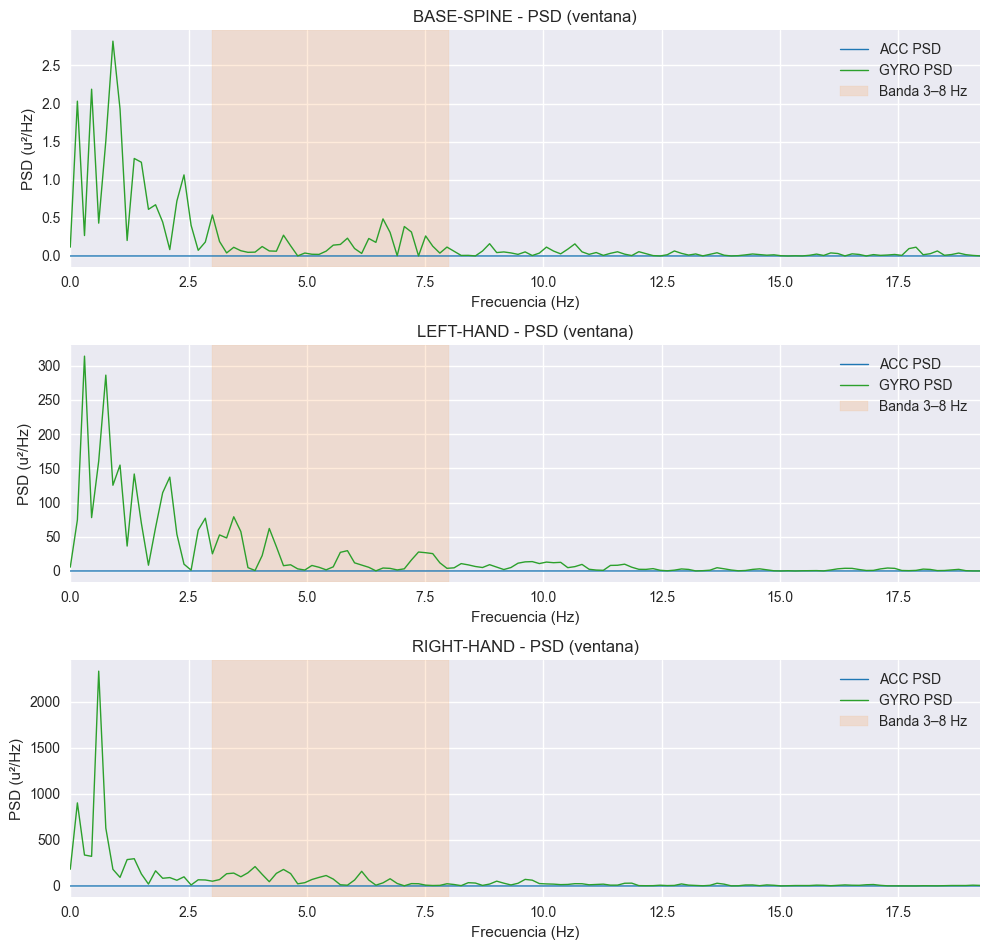

In [19]:
# Espectro (PSD) por dispositivo, destacando banda 3–8 Hz
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    # Asegurar estructura 1D para indexado por [i]
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        f_acc, P_acc = welch_psd(acc - np.mean(acc), fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro - np.mean(gyro), fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        # Banda 3–8 Hz
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda 3–8 Hz')
        # Anotación de pico si se detectó
        subres = [r for r in results if r.device==dev and r.is_tremor]
        if subres:
            # Mostrar pico más evidente (mayor ratio)
            rbest = sorted(subres, key=lambda r: r.ratio, reverse=True)[0]
            if np.isfinite(rbest.peak_freq_hz):
                ax.axvline(rbest.peak_freq_hz, color='#d62728', linestyle='--', alpha=0.7)
                ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                ax.text(rbest.peak_freq_hz, ymax*0.8, f"{rbest.peak_freq_hz:.2f} Hz", color='#d62728')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD (ventana)')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
elif px is not None:
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        f_acc, P_acc = welch_psd(acc - np.mean(acc), fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro - np.mean(gyro), fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=f_acc, y=P_acc, name='ACC PSD'))
        fig.add_trace(go.Scatter(x=f_gyro, y=P_gyro, name='GYRO PSD'))
        fig.add_vrect(x0=3.0, x1=8.0, fillcolor='orange', opacity=0.2, line_width=0)
        subres = [r for r in results if r.device==dev and r.is_tremor]
        if subres and np.isfinite(subres[0].peak_freq_hz):
            pf = subres[0].peak_freq_hz
            fig.add_vline(x=pf, line_dash='dash', line_color='red')
        fig.update_layout(title=f'{dev} - PSD', xaxis_title='Frecuencia (Hz)', yaxis_title='PSD (u²/Hz)')
        fig.update_xaxes(range=[0, min(20, (fs or 20)/2)])
        fig.show()
else:
    print('No hay backend de gráficos disponible (matplotlib/plotly).')

## Interpretación y notas

- El detector de temblor usa dos criterios combinados: (1) razón de potencia en banda 3–8 Hz respecto a 0.5–15 Hz ≥ 0.3 y (2) amplitud RMS del componente filtrado ≥ umbral (0.02 g en acelerómetro, 0.5 deg/s en giróscopo).
- La frecuencia pico reportada (si existe) indica el modo dominante del temblor en la ventana de 10 s.
- Si el registro total supera 10 s en común entre dispositivos, se usa una ventana centrada; si es más corto, se usa todo el segmento superpuesto.
- Para evaluar coherencia, compare LEFT-HAND vs RIGHT-HAND y con BASE-SPINE (este último debería mostrar menos energía en 3–8 Hz si el temblor es periférico).
- Ajuste los umbrales si la amplitud esperada es muy baja/alta en su hardware (sensibilidad IMU) o si el muestreo es atípico.


In [20]:
# Resumen legible de resultados
def pretty_bool(b):
    return 'SÍ' if bool(b) else 'NO'
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    display(summary[['device','signal','fs','peak_freq_hz','ratio','rms_tremor','is_tremor']].round(4))
    print('\nConclusiones por dispositivo (priorizando giróscopo):')
    for dev in devices:
        gyro_row = summary[(summary['device']==dev) & (summary['signal']=='gyro_mag')]
        acc_row = summary[(summary['device']==dev) & (summary['signal']=='acc_mag')]
        gflag = bool(gyro_row['is_tremor'].iloc[0]) if not gyro_row.empty else False
        aflag = bool(acc_row['is_tremor'].iloc[0]) if not acc_row.empty else False
        pf = float(gyro_row['peak_freq_hz'].iloc[0]) if not gyro_row.empty else float('nan')
        print(f" - {dev}: Temblor (gyro)={pretty_bool(gflag)}, f_pico≈{pf:.2f} Hz | Temblor (acc)={pretty_bool(aflag)}")
else:
    print('No hay resultados para mostrar.')

,device,signal,fs,peak_freq_hz,ratio,rms_tremor,is_tremor
0,BASE-SPINE,acc_mag,38.4615,3.9062,0.7331,0.0345,False
1,BASE-SPINE,gyro_mag,38.4615,3.0048,0.2855,0.6480,False
2,LEFT-HAND,acc_mag,38.4615,3.0048,0.2271,0.1270,False
3,LEFT-HAND,gyro_mag,38.4615,3.0048,0.2552,21.2797,False
4,RIGHT-HAND,acc_mag,38.4615,3.0048,0.1786,0.0728,False
5,RIGHT-HAND,gyro_mag,38.4615,3.3053,0.2824,24.9954,False



Conclusiones por dispositivo (priorizando giróscopo):
 - BASE-SPINE: Temblor (gyro)=NO, f_pico≈3.00 Hz | Temblor (acc)=NO
 - LEFT-HAND: Temblor (gyro)=NO, f_pico≈3.00 Hz | Temblor (acc)=NO
 - RIGHT-HAND: Temblor (gyro)=NO, f_pico≈3.31 Hz | Temblor (acc)=NO


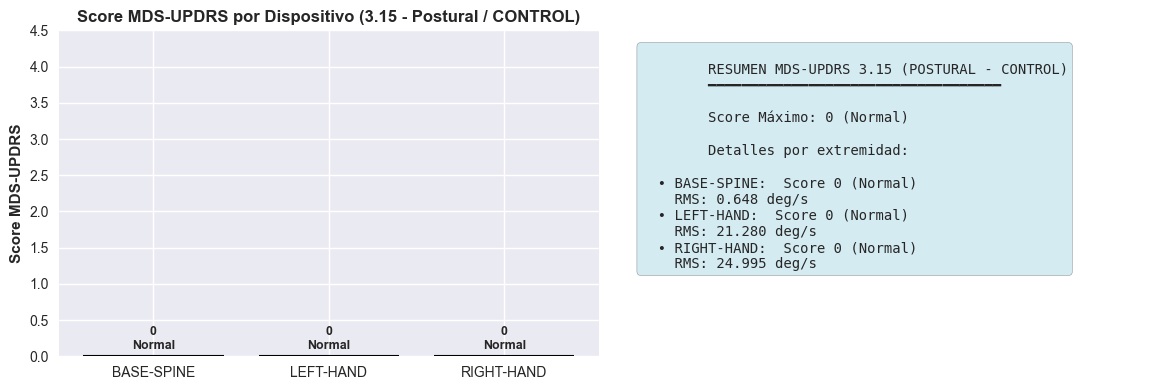


SCORES MDS-UPDRS 3.15 (CONTROL)
BASE-SPINE      | Score: 0 (Normal         ) | RMS: 0.6480
LEFT-HAND       | Score: 0 (Normal         ) | RMS: 21.2797
RIGHT-HAND      | Score: 0 (Normal         ) | RMS: 24.9954
MÁXIMO          | Score: 0


In [21]:

# IAG: Logica de clasificacion MDS-UPDRS asistida por IAG segun rangos definidos por el tutor.
# ============================================================================
# CÁLCULO DE SCORE MDS-UPDRS 3.15 (Temblor Postural - CONTROL)
# ============================================================================
# Score 0: Normal (sin temblor)
# Score 1: Leve (temblor detectado, gyro_rms < 1.0 deg/s)
# Score 2: Moderado-leve (1.0 ≤ gyro_rms < 3.0 deg/s)
# Score 3: Moderado (3.0 ≤ gyro_rms < 8.0 deg/s)
# Score 4: Severo (gyro_rms ≥ 8.0 deg/s)

def calculate_mds_updrs_score(gyro_rms: float, tremor_detected: bool) -> tuple:
    """Calcula score MDS-UPDRS (0-4) y etiqueta descriptiva."""
    if not tremor_detected:
        return (0, "Normal")
    if gyro_rms < 1.0:
        return (1, "Leve")
    elif gyro_rms < 3.0:
        return (2, "Moderado-leve")
    elif gyro_rms < 8.0:
        return (3, "Moderado")
    else:
        return (4, "Severo")

# Procesar scores por dispositivo/mano
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    scores_by_device = {}
    
    for dev in summary['device'].unique():
        dev_data = summary[summary['device'] == dev]
        gyro_data = dev_data[dev_data['signal'] == 'gyro_mag']
        
        if not gyro_data.empty:
            gyro_rms = gyro_data['rms_tremor'].iloc[0]
            tremor_detected = gyro_data['is_tremor'].iloc[0]
            score, label = calculate_mds_updrs_score(gyro_rms, tremor_detected)
            scores_by_device[dev] = {'score': score, 'label': label, 'gyro_rms': gyro_rms}
    
    # Máximo score entre todos los dispositivos
    max_score = max([s['score'] for s in scores_by_device.values()]) if scores_by_device else 0
    
    # Dashboard visual
    if _USE_MPL:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Gráfico 1: Scores por dispositivo
        devices = list(scores_by_device.keys())
        scores = [scores_by_device[d]['score'] for d in devices]
        colors = ['green' if s == 0 else 'yellow' if s in [1, 2] else 'orange' if s == 3 else 'red' for s in scores]
        
        bars = ax1.bar(devices, scores, color=colors, edgecolor='black', linewidth=1.5)
        ax1.set_ylabel('Score MDS-UPDRS', fontsize=11, fontweight='bold')
        ax1.set_ylim(0, 4.5)
        ax1.set_title('Score MDS-UPDRS por Dispositivo (3.15 - Postural / CONTROL)', fontweight='bold')
        ax1.axhline(y=0, color='k', linewidth=0.5)
        for i, (dev, score) in enumerate(zip(devices, scores)):
            label = scores_by_device[dev]['label']
            ax1.text(i, score + 0.1, f"{score}\n{label}", ha='center', fontsize=9, fontweight='bold')
        
        # Gráfico 2: Resumen global
        ax2.axis('off')
        summary_text = f"""
        RESUMEN MDS-UPDRS 3.15 (POSTURAL - CONTROL)
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        
        Score Máximo: {max_score} ({['Normal', 'Leve', 'Moderado-leve', 'Moderado', 'Severo'][max_score]})
        
        Detalles por extremidad:
        """
        for dev, data in sorted(scores_by_device.items()):
            summary_text += f"\n  • {dev}:  Score {data['score']} ({data['label']})"
            summary_text += f"\n    RMS: {data['gyro_rms']:.3f} deg/s"
        
        ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.15 (CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            print(f"{dev:15} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO':15} | Score: {max_score}")
        print("="*60)
    else:
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.15 (CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            print(f"{dev:15} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO':15} | Score: {max_score}")
        print("="*60)
else:
    print("No hay datos de 'summary' disponibles. Ejecute las celdas anteriores primero.")